In [4]:
packages <- c("tidyr", "dplyr", "readxl", "ggplot2")
missing_packages <- packages[!(packages %in% installed.packages()[, "Package"])]
if (length(missing_packages) > 0) install.packages(missing_packages, repos = "https://cloud.r-project.org")
invisible(lapply(packages, library, character.only = TRUE))
options(repr.plot.width = 10, repr.plot.height = 6)
options(warn = -1)

Data cleaning

In [6]:

# ==============================================================================
# 1. Load and Clean Urban Institute Medical Debt Data
# ==============================================================================
file_name <- 'changing_med_debt_landscape_state.xlsx'
link <- 'https://urban-data-catalog.s3.amazonaws.com/drupal-root-live/2024/07/02/changing_med_debt_landscape_state.xlsx'
if (!file.exists(file_name)) download.file(url = link, destfile = file_name, mode = "wb")
debt <- read_excel(file_name)
colnames(debt) <- c('year', 'fips', 'state', 'share', 'median',
                    'share_white', 'median_white', 'share_nw', 'median_nw',
                    'hospital', 'closure', 'uninsured', 'elderly', 'income')
debt <- debt %>%
  mutate(across(-state, ~ as.numeric(as.character(.)))) %>%
  mutate(state_name = state, state = fips) %>%
  select(-fips)
# ==============================================================================
# 2. Load and Clean UKCPR National Welfare Data
# ==============================================================================
file_name_welfare <- 'ukcpr_national_welfare_data_1980_2024_jan26update.xlsx'
link_welfare <- 'https://ukcpr.uky.edu/sites/default/files/2026-02/ukcpr_national_welfare_data_1980_2024_jan26update.xlsx'
if (!file.exists(file_name)) download.file(url = link, destfile = file_name, mode = "wb")
state_data <- read_excel(file_name_welfare, sheet = 2)
state_data <- state_data %>%
  select(-state) %>%
  rename('medicaid' = "Medicaid beneficiaries",
         'state_unemp' = "Unemployment rate",
         'state_income' = "Personal income",
         'state_poverty' = "Poverty Rate",
         'pop' = 'Population',
         'gdp' = "Gross State Product",
         'state_governor' = "Governor is Democrat (1=Yes)") %>%
  select(state_name, year, pop, medicaid, contains('state_')) %>%
  filter(year %in% 2011:2023) %>%
  mutate(state_governor = as.numeric(state_governor),
         log_income = log(state_income),
         log_pop = log(pop))
# ==============================================================================
# 3. Load and Clean US Census Bureau Population Data
# ==============================================================================
file1 <- 'sc-est2020int-alldata6.csv'
link1 <- 'https://www2.census.gov/programs-surveys/popest/datasets/2010-2020/intercensal/state/asrh/sc-est2020int-alldata6.csv'
file2 <- 'sc-est2024-alldata6.csv'
link2 <- 'https://www2.census.gov/programs-surveys/popest/datasets/2020-2024/state/asrh/sc-est2024-alldata6.csv'
if (!file.exists(file1)) download.file(url = link1, destfile = file1, mode = "wb")
if (!file.exists(file2)) download.file(url = link2, destfile = file2, mode = "wb")
pop1 <- read.csv(file1)
pop2 <- read.csv(file2)
mk <- intersect(colnames(pop1), colnames(pop2))
pop_combined <- pop1 %>% left_join(pop2, by = mk)
pop_combined <- pop_combined %>%
  rename_with(tolower) %>%
  mutate(fips = state) %>%
  select(-sumlev, -region, -division, -name, -estimatesbase2010, -estimatesbase2020, -census2020pop) %>%
  mutate(across(starts_with("popestimate"), ~ as.numeric(.)))
pop_long <- pop_combined %>%
  pivot_longer(cols = starts_with("popestimate"), names_to = "year", values_to = "pop_value") %>%
  mutate(year = gsub('popestimate', '', year),
         year = as.numeric(year))
# Calculate Age Cohorts
total_pop <- pop_long %>% filter(sex == 0 & origin == 0) %>%
  group_by(fips, year) %>% summarise(total_pop = sum(pop_value), .groups = 'drop')
treated <- pop_long %>% filter(age >= 30 & age < 50 & sex == 0 & origin == 0) %>%
  group_by(fips, year) %>% summarise(age3049 = sum(pop_value), .groups = 'drop')
young <- pop_long %>% filter(age <= 18 & sex == 0 & origin == 0) %>%
  group_by(fips, year) %>% summarise(young = sum(pop_value), .groups = 'drop')
old <- pop_long %>% filter(age >= 65 & sex == 0 & origin == 0) %>%
  group_by(fips, year) %>% summarise(old = sum(pop_value), .groups = 'drop')
white <- pop_long %>% filter(sex == 0 & origin == 1 & race == 1) %>%
  group_by(fips, year) %>% summarise(white = sum(pop_value), .groups = 'drop')
black <- pop_long %>% filter(sex == 0 & origin == 1 & race == 2) %>%
  group_by(fips, year) %>% summarise(black = sum(pop_value), .groups = 'drop')
hispanic <- pop_long %>% filter(sex == 0 & origin == 2) %>%
  group_by(fips, year) %>% summarise(hispanic = sum(pop_value), .groups = 'drop')
POP <- total_pop %>%
  left_join(treated,  by = c('fips', 'year')) %>%
  left_join(young,    by = c('fips', 'year')) %>%
  left_join(old,      by = c('fips', 'year')) %>%
  left_join(white,    by = c('fips', 'year')) %>%
  left_join(black,    by = c('fips', 'year')) %>%
  left_join(hispanic, by = c('fips', 'year')) %>%
  rename(state = fips)
POP <- POP %>% mutate(
  white     = white / total_pop,
  black     = black / total_pop,
  hispanic  = hispanic / total_pop,
  pop_share = age3049 / total_pop,
  young     = young / total_pop,
  old       = old / total_pop)
# Merge datasets and clear environment
data <- debt %>%
  left_join(state_data, by = c('state_name', 'year')) %>%
  left_join(POP, by = c('state', 'year'))
save(data, file = 'data.RDa')

Descriptive statistics plots

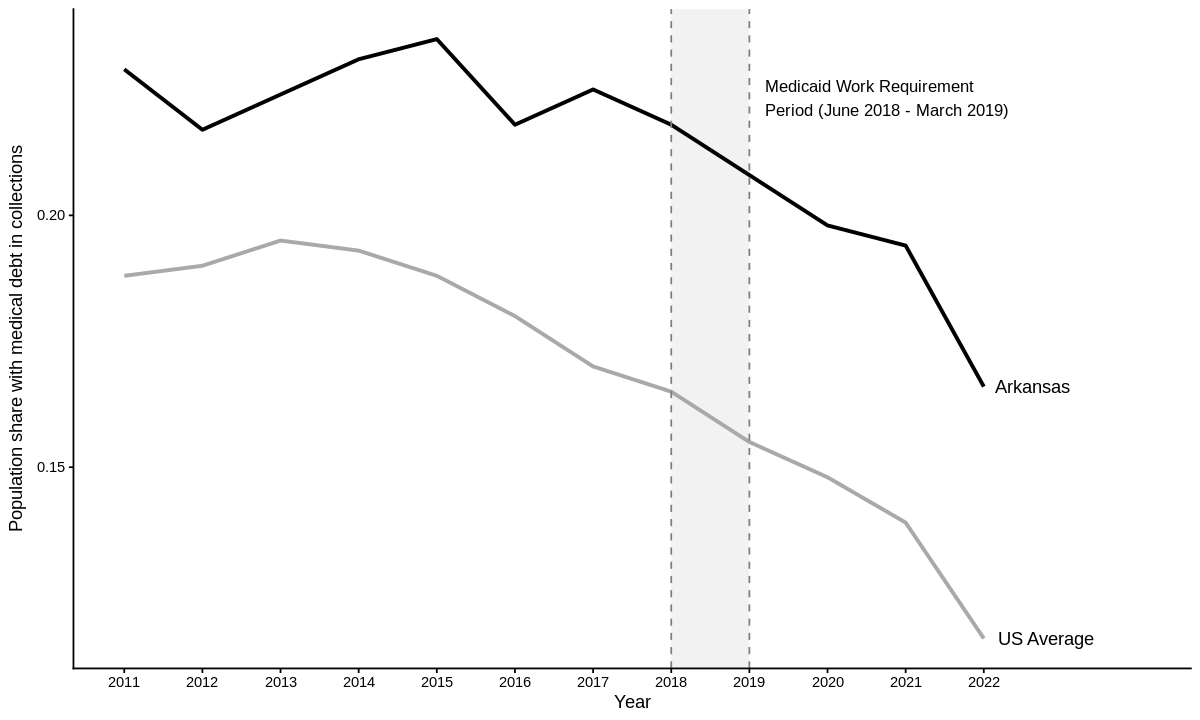

In [10]:

# ==============================================================================
# 4. Generate Graphics
# ==============================================================================
load('data.RDa')
file_name_us <- 'changing_med_debt_landscape_national.xlsx'
link_us <- 'https://urban-data-catalog.s3.amazonaws.com/drupal-root-live/2024/07/02/changing_med_debt_landscape_national.xlsx'
if (!file.exists(file_name_us)) download.file(url = link_us, destfile = file_name_us, mode = "wb")
us <- read_excel(file_name_us)
colnames(us) <- c('year', 'state', 'share', 'median',
                  'share_white', 'median_white', 'share_nw', 'median_nw',
                  'hospital', 'closure', 'uninsured', 'elderly', 'income')
us <- us %>% mutate(across(-state, ~ as.numeric(as.character(.)))) %>% filter(year < 2023)
ar <- data %>%
  filter(state_name == 'AR' & year < 2023) %>%
  mutate(medicaid = medicaid / pop) %>%
  select(year, share, median, medicaid)
usm <- data %>% # Medicaid
  filter(year < 2023) %>%
  group_by(year) %>%
  summarize(medicaid_total = sum(medicaid, na.rm = TRUE), pop_total = sum(pop, na.rm = TRUE)) %>%
  mutate(medicaid = medicaid_total / pop_total) %>%
  ungroup()
# Plot 1: Debt Share
max_share_ar <- max(ar$share, na.rm = TRUE)
ggplot() +
  annotate("rect", xmin = 2018, xmax = 2019, ymin = -Inf, ymax = Inf, fill = "grey90", alpha = 0.5) +
  annotate("text", x = 2019.2, y = max_share_ar * 0.95,
           label = "Medicaid Work Requirement\nPeriod (June 2018 - March 2019)",
           color = "black", size = 3.5, hjust = 0) +
  geom_line(data = ar, aes(x = year, y = share), size = 1.1, color = 'black') +
  geom_line(data = us, aes(x = year, y = share), size = 1.1, color = 'darkgrey') +
  geom_vline(xintercept = c(2018, 2019), linetype = "dashed", color = "grey50") +
  geom_text(data = filter(ar, year == max(year)), aes(x = year, y = share, label = "Arkansas"), hjust = -0.15) +
  geom_text(data = filter(us, year == max(year)), aes(x = year, y = share, label = "US Average"), hjust = -0.15) +
  scale_x_continuous(breaks = 2011:2022, limits = c(2011, 2024)) +
  labs(x = "Year", y = "Population share with medical debt in collections") +
  theme_classic()
ggsave('plot_debt_share.png', height = 4, width = 7)

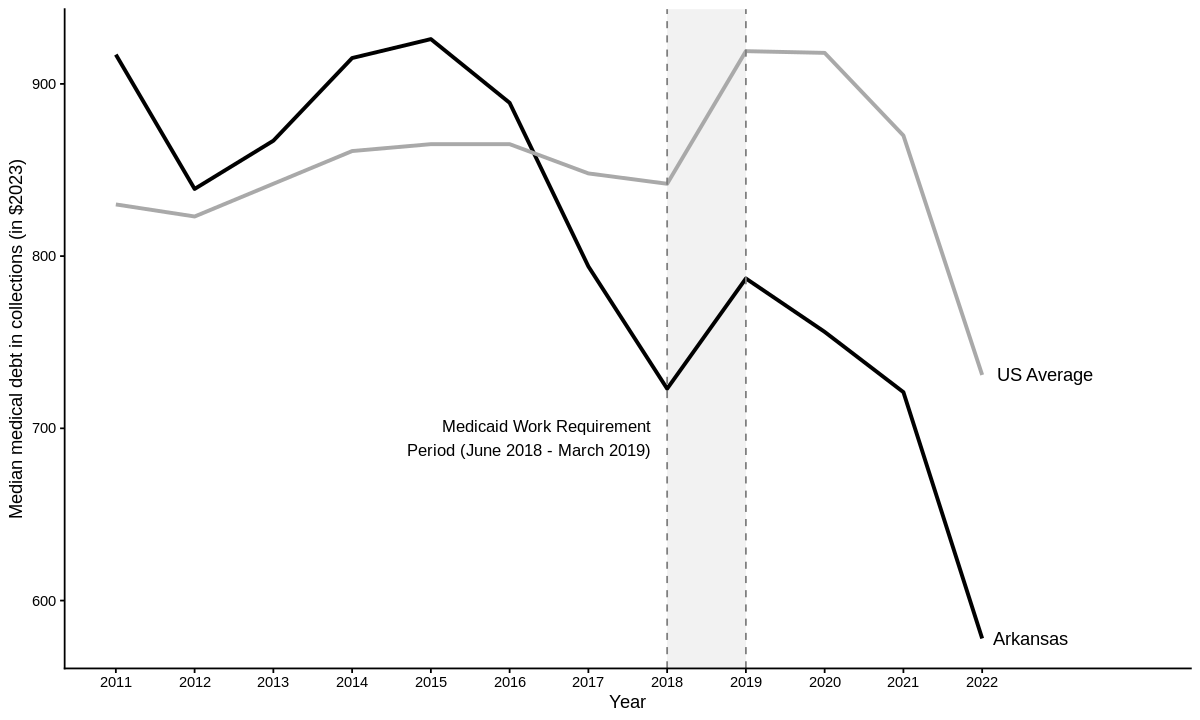

In [15]:

# Plot 2: Debt Median
max_median_ar <- max(ar$median, na.rm = TRUE)
ggplot() +
  annotate("rect", xmin = 2018, xmax = 2019, ymin = -Inf, ymax = Inf, fill = "grey90", alpha = 0.5) +
  annotate("text", x = 2017.8, y = max_median_ar * 0.75,
           label = "Medicaid Work Requirement\nPeriod (June 2018 - March 2019)",
           color = "black", size = 3.5, hjust = 1) +
  geom_line(data = ar, aes(x = year, y = median), size = 1.1, color = 'black') +
  geom_line(data = us, aes(x = year, y = median), size = 1.1, color = 'darkgrey') +
  geom_vline(xintercept = c(2018, 2019), linetype = "dashed", color = "grey50") +
  geom_text(data = filter(ar, year == max(year)), aes(x = year, y = median, label = "Arkansas"), hjust = -0.15) +
  geom_text(data = filter(us, year == max(year)), aes(x = year, y = median, label = "US Average"), hjust = -0.15) +
  scale_x_continuous(breaks = 2011:2022, limits = c(2011, 2024)) +
  labs(x = "Year", y = "Median medical debt in collections (in $2023)") +
  theme_classic()

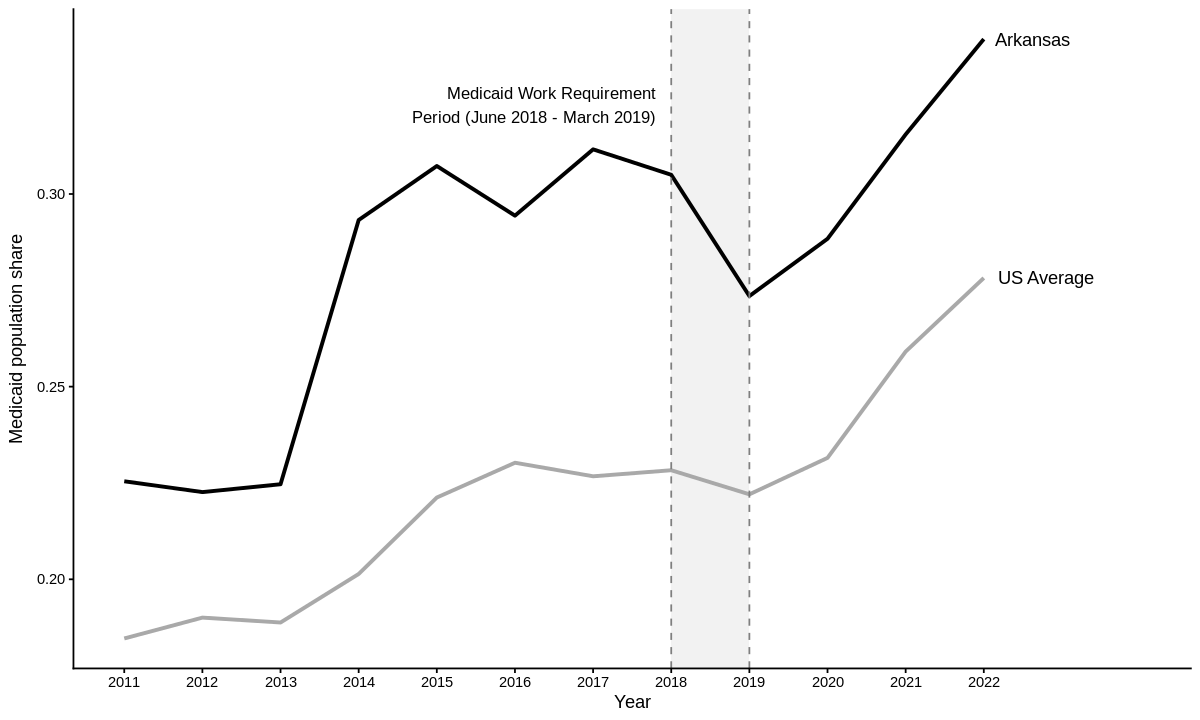

In [16]:
# Plot 3: Medicaid Share
max_medicaid_ar <- max(ar$medicaid, na.rm = TRUE)
ggplot() +
  annotate("rect", xmin = 2018, xmax = 2019, ymin = -Inf, ymax = Inf, fill = "grey90", alpha = 0.5) +
  annotate("text", x = 2017.8, y = max_medicaid_ar * 0.95,
           label = "Medicaid Work Requirement\nPeriod (June 2018 - March 2019)",
           color = "black", size = 3.5, hjust = 1) +
  geom_line(data = ar, aes(x = year, y = medicaid), size = 1.1, color = 'black') +
  geom_line(data = usm, aes(x = year, y = medicaid), size = 1.1, color = 'darkgrey') +
  geom_vline(xintercept = c(2018, 2019), linetype = "dashed", color = "grey50") +
  geom_text(data = filter(ar, year == max(year)), aes(x = year, y = medicaid, label = "Arkansas"), hjust = -0.15) +
  geom_text(data = filter(usm, year == max(year)), aes(x = year, y = medicaid, label = "US Average"), hjust = -0.15) +
  scale_x_continuous(breaks = 2011:2022, limits = c(2011, 2024)) +
  labs(x = "Year", y = "Medicaid population share") +
  theme_classic()
ggsave('plot_medicaid.png', height = 4, width = 7)